In [2]:

# CELL 0: IMPORTS
# ============================================================================


import pandas as pd
import requests
import os
import time
import random
import json
import hashlib
from datetime import datetime
from typing import Dict, List, Tuple, Optional
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set pandas display options
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 20)

In [12]:
# CELL 1: FIXED CONFIGURATION
# ============================================================================


# Fixed Configuration
class Config:
    # API Configuration - FIXED ISSUES
    OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "YOUR_API_KEY_HERE")  # Use environment variable
    MODEL = "gpt-4o-mini-2024-07-18"  # ← FIXED: Removed trailing comma
    ALTERNATIVE_MODELS = ["gpt-3.5-turbo", "gpt-4o-mini"]  # Fallback options
    
    # Rate Limiting (Improved)
    BASE_DELAY = 1.0           # Base delay between requests
    MAX_RETRIES = 3            # Reduced retries for faster debugging
    REQUEST_TIMEOUT = 30       # Request timeout
    BATCH_SIZE = 5             # Process in smaller batches
    
    # Testing Configuration
    SAMPLE_SIZE = 20             # Start very small for testing
    RANDOM_STATE = 41          # Reproducible results
    DATASET_PATH = "data/product_info_01.csv" # Your dataset
    PROMPTS_FOLDER = "prompts" # Prompts folder
    
    # Results & Caching
    RESULTS_FOLDER = "results"
    CACHE_RESULTS = True       # Cache API responses (saves money!)
    CACHE_FILE = "api_cache.json"
    
    # Prompts to test
    PROMPTS_TO_TEST = [
        "prompt_HCP",       
        "prompt_01",
        "prompt_reasoning_classification" 
    ]

# Global configuration instance
config = Config()

print("✅ Fixed Configuration Loaded")
print(f"📊 Will test {len(config.PROMPTS_TO_TEST)} prompts on {config.SAMPLE_SIZE} samples")
print(f"💾 Caching enabled: {config.CACHE_RESULTS}")
print(f"📁 Results will be saved to: {config.RESULTS_FOLDER}/")
print(f"🤖 Model: {config.MODEL} (type: {type(config.MODEL)})")

# Validation
issues = []
if config.OPENAI_API_KEY in ["YOUR_API_KEY_HERE", "", None]:
    issues.append("⚠️ OpenAI API key not set - Please set OPENAI_API_KEY environment variable")
if not os.path.exists(config.DATASET_PATH):
    issues.append(f"⚠️ Dataset not found: {config.DATASET_PATH}")
if not os.path.exists(config.PROMPTS_FOLDER):
    issues.append(f"⚠️ Prompts folder not found: {config.PROMPTS_FOLDER}")

if issues:
    print("\n❌ Configuration Issues:")
    for issue in issues:
        print(f"   {issue}")
else:
    print("\n✅ Configuration validated successfully!")

# Test API key format
if config.OPENAI_API_KEY and config.OPENAI_API_KEY.startswith('sk-'):
    print("✅ API key format looks correct")
else:
    print("❌ API key format looks incorrect - should start with 'sk-'")

✅ Fixed Configuration Loaded
📊 Will test 3 prompts on 20 samples
💾 Caching enabled: True
📁 Results will be saved to: results/
🤖 Model: gpt-4o-mini-2024-07-18 (type: <class 'str'>)

✅ Configuration validated successfully!
✅ API key format looks correct


In [13]:
# CELL 2: ENHANCED API CLIENT WITH CACHING - Run this second
# ============================================================================

class EnhancedAPIClient:
    """Enhanced API client with caching, fallbacks, and better error handling"""
    
    def __init__(self):
        self.cache = {}
        self.load_cache()
        self.request_count = 0
        self.cache_hits = 0
        
    def load_cache(self):
        """Load cached responses from disk"""
        if config.CACHE_RESULTS and os.path.exists(config.CACHE_FILE):
            try:
                with open(config.CACHE_FILE, 'r') as f:
                    self.cache = json.load(f)
                print(f"📂 Loaded {len(self.cache)} cached API responses")
            except Exception as e:
                print(f"⚠️ Error loading cache: {e}")
                self.cache = {}
        else:
            self.cache = {}
    
    def save_cache(self):
        """Save cache to disk"""
        if config.CACHE_RESULTS:
            try:
                os.makedirs(os.path.dirname(config.CACHE_FILE) if os.path.dirname(config.CACHE_FILE) else '.', exist_ok=True)
                with open(config.CACHE_FILE, 'w') as f:
                    json.dump(self.cache, f, indent=2)
            except Exception as e:
                print(f"⚠️ Error saving cache: {e}")
    
    def get_cache_key(self, system_prompt: str, user_prompt: str, model: str) -> str:
        """Generate unique cache key"""
        content = f"{system_prompt}||{user_prompt}||{model}"
        return hashlib.md5(content.encode()).hexdigest()
    
    def chat(self, system_prompt: str, user_prompt: str, max_tokens: int = 50) -> tuple:
        """Enhanced chat with caching and fallback models"""
        
        # Generate cache key
        cache_key = self.get_cache_key(system_prompt, user_prompt, config.MODEL)
        
        # Check cache first
        if config.CACHE_RESULTS and cache_key in self.cache:
            self.cache_hits += 1
            cached = self.cache[cache_key]
            return cached['content'], cached['response']
        
        # Make API request
        self.request_count += 1
        
        # Try primary model, then fallbacks
        models_to_try = [config.MODEL] + [m for m in config.ALTERNATIVE_MODELS 
                                        if m != config.MODEL]
        
        for model in models_to_try:
            try:
                content, response = self._make_request(
                    system_prompt, user_prompt, max_tokens, model
                )
                
                # Cache successful response
                if config.CACHE_RESULTS:
                    self.cache[cache_key] = {
                        'content': content,
                        'response': response,
                        'model_used': model,
                        'timestamp': datetime.now().isoformat()
                    }
                    self.save_cache()
                
                return content, response
                
            except Exception as e:
                print(f"    ❌ Model {model} failed: {str(e)[:100]}...")
                if model == models_to_try[-1]:  # Last model
                    raise e
                print(f"    🔄 Trying fallback model...")
        
        raise Exception("All models failed")
    
    def _make_request(self, system_prompt: str, user_prompt: str, 
                 max_tokens: int, model: str) -> tuple:
        """Make the actual API request - Updated for reasoning models"""
        
        url = "https://api.openai.com/v1/chat/completions"
        headers = {
            "Content-Type": "application/json",
            "Authorization": f"Bearer {config.OPENAI_API_KEY}",
        }

        # Different parameters for reasoning models vs regular models
        if model.startswith("o1"):
            # o1 models don't support system messages or many parameters
            data = {
                "model": model,
                "messages": [
                    {
                        "role": "user", 
                        "content": f"{system_prompt}\n\n{user_prompt}"  # Combine system and user
                    }
                ],
                "max_completion_tokens": max_tokens,  # Different parameter name
            }
        else:
            # Regular models (fallback)
            data = {
                "model": model,
                "messages": [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                "max_tokens": max_tokens,
                "temperature": 0.0,
                "top_p": 1.0
            }

        for attempt in range(config.MAX_RETRIES):
            try:
                if attempt > 0:
                    wait_time = (2 ** attempt) + random.uniform(0, 1)
                    print(f"    ⏳ Retry {attempt + 1}/{config.MAX_RETRIES} in {wait_time:.1f}s")
                    time.sleep(wait_time)
                
                response = requests.post(url, headers=headers, json=data, 
                                    timeout=config.REQUEST_TIMEOUT)
                
                if response.status_code == 200:
                    response_data = response.json()
                    content = response_data["choices"][0]["message"]["content"]
                    return content, response_data
                    
                elif response.status_code == 429:
                    if attempt < config.MAX_RETRIES - 1:
                        wait_time = (2 ** attempt) + random.uniform(5, 10)  # Longer waits
                        print(f"    🚦 Rate limit. Waiting {wait_time:.1f}s...")
                        time.sleep(wait_time)
                        continue
                    else:
                        raise Exception("Rate limit exceeded after all retries")
                else:
                    response.raise_for_status()
                    
            except requests.exceptions.RequestException as e:
                if attempt < config.MAX_RETRIES - 1:
                    wait_time = (2 ** attempt) + random.uniform(0, 1)
                    print(f"    ❌ Request error: {e}. Retrying in {wait_time:.1f}s...")
                    time.sleep(wait_time)
                    continue
                else:
                    raise e
        
        raise Exception(f"Failed after {config.MAX_RETRIES} attempts")
    
    def get_stats(self):
        """Get API usage statistics"""
        return {
            'total_requests': self.request_count,
            'cache_hits': self.cache_hits,
            'cache_size': len(self.cache),
            'cache_hit_rate': f"{(self.cache_hits / max(self.request_count + self.cache_hits, 1) * 100):.1f}%"
        }

# Initialize global API client
api_client = EnhancedAPIClient()

print("✅ Enhanced API Client loaded")
print(f"📊 API Stats: {api_client.get_stats()}")

📂 Loaded 481 cached API responses
✅ Enhanced API Client loaded
📊 API Stats: {'total_requests': 0, 'cache_hits': 0, 'cache_size': 481, 'cache_hit_rate': '0.0%'}


In [14]:
# CELL 3: ENHANCED UTILITY FUNCTIONS - Run this third
# ============================================================================

def get_prompt(prompt_name: str) -> str:
    """Load prompt from file with better error handling"""
    try:
        prompt_path = os.path.join(config.PROMPTS_FOLDER, f"{prompt_name}.md")
        with open(prompt_path, 'r', encoding='utf-8') as f:
            content = f.read().strip()
            if not content:
                raise ValueError(f"Prompt file {prompt_name}.md is empty")
            return content
    except FileNotFoundError:
        print(f"❌ Prompt file not found: {prompt_path}")
        print(f"💡 Make sure the file exists in the '{config.PROMPTS_FOLDER}' folder")
        return ""
    except Exception as e:
        print(f"❌ Error loading prompt {prompt_name}: {e}")
        return ""

def parse_category_output(response: str) -> tuple:
    """Enhanced response parsing with confidence detection"""
    import re
    
    response = response.strip()
    confidence = "unknown"
    
    # Handle Chain-of-Thought format (REASONING: ... CATEGORY: ... CONFIDENCE: ...)
    if "CATEGORY:" in response:
        category_match = re.search(r"CATEGORY:\s*(.+?)(?:\n|CONFIDENCE:|$)", response, re.IGNORECASE)
        confidence_match = re.search(r"CONFIDENCE:\s*(.+?)(?:\n|$)", response, re.IGNORECASE)
        
        if category_match:
            category = category_match.group(1).strip().strip('"').strip("'")
            if confidence_match:
                confidence = confidence_match.group(1).strip()
            return category, confidence
    
    # Handle regular "Category:" format
    if "Category:" in response:
        category_match = re.search(r"Category:\s*(.+?)(?:\n|$)", response, re.IGNORECASE)
        if category_match:
            category = category_match.group(1).strip().strip('"').strip("'")
            return category, confidence
    
    # Handle direct category output (first line)
    first_line = response.split('\n')[0].strip().strip('"').strip("'")
    
    if '/' in first_line and len(first_line) > 0:
        return first_line, confidence
    else:
        print(f"    ⚠️ Unexpected format: '{first_line[:1000]}...'")
        return first_line if first_line else "unknown", confidence

def classify_product(description: str, system_prompt: str, max_tokens: int = 50) -> dict:
    """Classify a single product with enhanced tracking"""
    user_prompt = f"Product concatenated_product: {description}"
    
    try:
        # Rate limiting
        time.sleep(config.BASE_DELAY)
        
        # Make API call
        answer_raw, full_response = api_client.chat(
            system_prompt=system_prompt,
            user_prompt=user_prompt,
            max_tokens=max_tokens
        )
        
        # Parse response
        predicted_category, confidence = parse_category_output(answer_raw)
        
        return {
            'predicted_category': predicted_category,
            'confidence': confidence,
            'raw_response': answer_raw,
            'tokens_used': full_response.get('usage', {}).get('total_tokens', 0),
            'model_used': full_response.get('model', config.MODEL),
            'timestamp': datetime.now().isoformat(),
            'status': 'success'
        }
        
    except Exception as e:
        print(f"    ❌ Classification error: {e}")
        return {
            'predicted_category': 'error',
            'confidence': 'error',
            'raw_response': str(e),
            'tokens_used': 0,
            'model_used': 'error',
            'timestamp': datetime.now().isoformat(),
            'status': 'error'
        }

def calculate_metrics(true_categories: list, predicted_categories: list) -> dict:
    """Calculate comprehensive evaluation metrics"""
    
    # Filter out errors
    valid_pairs = [(t, p) for t, p in zip(true_categories, predicted_categories) 
                   if p != 'error']
    
    if not valid_pairs:
        return {
            'exact_accuracy': 0.0,
            'partial_accuracy': 0.0,
            'exact_matches': 0,
            'partial_matches': 0,
            'valid_predictions': 0,
            'error_count': len(predicted_categories)
        }
    
    valid_true, valid_predicted = zip(*valid_pairs)
    
    # Exact matches
    exact_matches = sum(1 for t, p in valid_pairs if t == p)
    exact_accuracy = exact_matches / len(valid_pairs)
    
    # Partial matches (first category level)
    partial_matches = sum(1 for t, p in valid_pairs 
                         if t.split('/')[0] == p.split('/')[0])
    partial_accuracy = partial_matches / len(valid_pairs)
    
    return {
        'exact_accuracy': exact_accuracy,
        'partial_accuracy': partial_accuracy,
        'exact_matches': exact_matches,
        'partial_matches': partial_matches,
        'valid_predictions': len(valid_pairs),
        'error_count': len(predicted_categories) - len(valid_pairs)
    }

print("✅ Enhanced utility functions loaded")
print("🔧 Functions: get_prompt, parse_category_output, classify_product, calculate_metrics")

✅ Enhanced utility functions loaded
🔧 Functions: get_prompt, parse_category_output, classify_product, calculate_metrics


In [15]:
# CELL 4: LOAD AND PREVIEW DATA - Run this fourth
# ============================================================================

def load_and_preview_data():
    """Load dataset with enhanced error handling and preview"""
    
    try:
        # Try different encodings and delimiters
        encodings_to_try = ['ISO-8859-1', 'utf-8', 'cp1252']
        delimiters_to_try = [';', ',', '\t']
        
        df = None
        for encoding in encodings_to_try:
            for delimiter in delimiters_to_try:
                try:
                    df = pd.read_csv(config.DATASET_PATH, 
                                   delimiter=delimiter, 
                                   encoding=encoding)
                    
                    # Clean column names (remove BOM)
                    df.columns = [col.replace('ï»¿', '').strip() for col in df.columns]

                    df['concatenated_product'] = df['brand'].astype(str) + '-' + df['itemDescriptionEN'].astype(str) + '-' + df['description'].astype(str)
                    
                    # Check if we have required columns
                    if 'concatenated_product' in df.columns and 'encodeNameEN' in df.columns:
                        print(f"✅ Dataset loaded with encoding={encoding}, delimiter='{delimiter}'")
                        break
                        
                except Exception:
                    continue
            if df is not None:
                break
        
        if df is None:
            raise Exception("Could not load dataset with any encoding/delimiter combination")
        
        print(f"📊 Dataset shape: {df.shape}")
        print(f"📋 Columns: {list(df.columns)}")
        
        # Validate required columns
        required_cols = ['concatenated_product', 'encodeNameEN']
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            print(f"❌ Missing required columns: {missing_cols}")
            return None
        
        # Clean data
        df = df.dropna(subset=['concatenated_product', 'encodeNameEN'])
        df['concatenated_product'] = df['concatenated_product'].astype(str).str.strip()
        df['encodeNameEN'] = df['encodeNameEN'].astype(str).str.strip()
        
        print(f"📊 After cleaning: {df.shape}")
        
        # Sample data for testing
        test_df = df.sample(n=min(config.SAMPLE_SIZE, len(df)), 
                           random_state=config.RANDOM_STATE)
        
        print(f"\n📋 Preview of {len(test_df)} test samples:")
        display(test_df[['encodeNameEN', 'concatenated_product']].head())
        
        print(f"\n📊 Category distribution in test sample:")
        category_counts = test_df['encodeNameEN'].value_counts()
        for cat, count in category_counts.items():
            print(f"  • {cat}: {count}")
        
        # Show data quality info
        print(f"\n📈 Data Quality:")
        print(f"  • Average description length: {df['concatenated_product'].str.len().mean():.0f} chars")
        print(f"  • Unique categories: {df['encodeNameEN'].nunique()}")
        print(f"  • Most common category: {df['encodeNameEN'].mode().iloc[0]}")
        
        return df, test_df
        
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        print(f"💡 Make sure '{config.DATASET_PATH}' exists and has the correct format")
        return None, None

# Load the data
full_df, test_df = load_and_preview_data()

if test_df is not None:
    print(f"\n✅ Data loaded successfully! Ready for evaluation.")
else:
    print(f"\n❌ Data loading failed. Please check your dataset.")

✅ Dataset loaded with encoding=ISO-8859-1, delimiter=','
📊 Dataset shape: (15968, 8)
📋 Columns: ['ref', 'itemDescriptionEN', 'brand', 'nameEN', 'encodeNameEN', 'title', 'description', 'concatenated_product']
📊 After cleaning: (15966, 8)

📋 Preview of 20 test samples:


,encodeNameEN,concatenated_product
12498,health-care/nebulizers,Terpenic-Diffuser Pulse-The Diffuser Pulse utilizes ultrasonic water vaporization technology wit...
11775,mom-baby/maternity-essentials/strollers-accessories,MomCozy-Adjustable Pillow-Discover Momcozy Adjustable Pregnancy and Nursing Pillowâyour ultima...
11757,hair/dry-damaged-hair/shampoo,Haan-Hair Shampoo-The sulfate-free Hair Shampoo cares for your hair from root to tip.Its prebiot...
178,skin/loss-firmness/specific-moisturizers,La Prairie-Skin Caviar Luxe Cream Sheer -Skin Caviar Luxe Cream Sheeris anindulgent lifting andf...
2911,skin/cleansers-tonners,"Clarins-Soothing Gentle Foaming Cleanser-Discover CLARINS Soothing Gentle Foaming Cleanser, a so..."



📊 Category distribution in test sample:
  • mom-baby/maternity-essentials/strollers-accessories: 2
  • health-care/nebulizers: 1
  • hair/dry-damaged-hair/shampoo: 1
  • skin/loss-firmness/specific-moisturizers: 1
  • skin/cleansers-tonners: 1
  • skin/dark-spots/seruns: 1
  • skin/dark-spots/specific-moisturizers: 1
  • skin/cleansers-tonners/normal-skin: 1
  • health-care/diabetics: 1
  • hair/contitioner/hair-loss: 1
  • health-care/nutrition: 1
  • body/exfoliators: 1
  • makeup/eyes-brows/eyebrows: 1
  • skin/first-signs-age/specific-moisturizers: 1
  • skin/cleansers-tonners/combination-to-oily-skin: 1
  • skin/oiliness-acne-pores/essences-preparing-lotions: 1
  • mom-baby/first-years/first-teeth: 1
  • men/shaving/shaving: 1
  • hair/styling: 1

📈 Data Quality:
  • Average description length: 817 chars
  • Unique categories: 362
  • Most common category: fragrance/women

✅ Data loaded successfully! Ready for evaluation.


In [16]:
# CELL 6: SINGLE PROMPT EVALUATION - Test one prompt at a time
# ============================================================================

def evaluate_single_prompt(prompt_name: str, test_data: pd.DataFrame = None, 
                          verbose: bool = True) -> dict:
    """Evaluate a single prompt with detailed results"""
    
    if test_data is None:
        if test_df is None:
            print("❌ No test data available. Run Cell 4 first.")
            return None
        test_data = test_df
    
    if verbose:
        print(f"🧪 EVALUATING: {prompt_name}")
        print("=" * 50)
    
    # Load prompt
    system_prompt = get_prompt(prompt_name)
    if not system_prompt:
        return None
    
    if verbose:
        print(f"📝 Prompt loaded: {len(system_prompt)} characters")
        print(f"📊 Testing on {len(test_data)} samples...")
    
    # Classify all products
    results = []
    concatenated_products = test_data['concatenated_product'].tolist()
    true_categories = test_data['encodeNameEN'].tolist()
    
    print(f"\n🔄 Classifying products...")
    
    for i, (concatenated_product, true_category) in enumerate(zip(concatenated_products, true_categories)):
        if verbose and (i % 2 == 0 or i == len(concatenated_products) - 1):
            print(f"   Progress: {i+1}/{len(concatenated_products)} ({((i+1)/len(concatenated_products)*100):.0f}%)")
        
        # Classify product
        result = classify_product(concatenated_product, system_prompt)
        
        # Add true category and matching info
        result.update({
            'concatenated_product': concatenated_product,
            'true_category': true_category,
            'exact_match': true_category == result['predicted_category'],
            'partial_match': (true_category.split('/')[0] == 
                            result['predicted_category'].split('/')[0]),
            'prompt_name': prompt_name
        })
        
        results.append(result)
    
    # Calculate metrics
    predicted_categories = [r['predicted_category'] for r in results]
    metrics = calculate_metrics(true_categories, predicted_categories)
    
    # Create summary
    evaluation_result = {
        'prompt_name': prompt_name,
        'total_samples': len(test_data),
        'metrics': metrics,
        'results': results,
        'api_stats': api_client.get_stats(),
        'timestamp': datetime.now().isoformat()
    }
    
    if verbose:
        print(f"\n📊 RESULTS FOR {prompt_name}:")
        print(f"   ✅ Exact Accuracy: {metrics['exact_accuracy']:.1%} ({metrics['exact_matches']}/{metrics['valid_predictions']})")
        print(f"   📊 Partial Accuracy: {metrics['partial_accuracy']:.1%} ({metrics['partial_matches']}/{metrics['valid_predictions']})")
        print(f"   ❌ Errors: {metrics['error_count']}")
        print(f"   🔧 API Stats: {api_client.get_stats()}")
        
        # Show some example results
        print(f"\n📋 Sample Results:")
        for i, result in enumerate(results[:3]):
            status = "✅" if result['exact_match'] else "❌"
            print(f"   {status} {result['true_category']} → {result['predicted_category']}")
    
    return evaluation_result

# Example usage - uncomment to test a single prompt:

print(test_df)

single_result = evaluate_single_prompt("prompt_01", test_df)

print("✅ Single prompt evaluation function loaded")
print("💡 Use: evaluate_single_prompt('prompt_name') to test individual prompts")

            ref                                         itemDescriptionEN  \
12498  019708TX                                            Diffuser Pulse   
11775  023942C1                                         Adjustable Pillow   
11757  018982ZN                                              Hair Shampoo   
178    003972LP                             Skin Caviar Luxe Cream Sheer    
2911   002631CS                          Soothing Gentle Foaming Cleanser   
14136  008175MT                                  Glycolic +E + F Ampoules   
2809   018574DL                                Biolumin-C Gel Moisturizer   
2919   022512JI                                    Hyaluage Micelar Water   
265    003984AK          Akildia Multi-Protective Cream for Diabetic Feet   
4994   022787WY                      Cica Peptide Derma Scalp Conditioner   
1142   022062VX                         Debloat and Detox Food Supplement   
3992   016007AY                   Rituel Douceur Exfoliating Body Granita   

📝 Prompt loaded: 12993 characters
📊 Testing on 20 samples...

🔄 Classifying products...
   Progress: 1/20 (5%)
   Progress: 3/20 (15%)
   Progress: 5/20 (25%)
   Progress: 7/20 (35%)
   Progress: 9/20 (45%)
   Progress: 11/20 (55%)
   Progress: 13/20 (65%)
   Progress: 15/20 (75%)
   Progress: 17/20 (85%)
   Progress: 19/20 (95%)
   Progress: 20/20 (100%)

📊 RESULTS FOR prompt_01:
   ✅ Exact Accuracy: 30.0% (6/20)
   📊 Partial Accuracy: 90.0% (18/20)
   ❌ Errors: 0
   🔧 API Stats: {'total_requests': 20, 'cache_hits': 0, 'cache_size': 501, 'cache_hit_rate': '0.0%'}

📋 Sample Results:
   ❌ health-care/nebulizers → body/beauty-tech
   ❌ mom-baby/maternity-essentials/strollers-accessories → mom-baby/after-birth/breast-feeding
   ❌ hair/dry-damaged-hair/shampoo → hair/shampoo
✅ Single prompt evaluation function loaded
💡 Use: evaluate_single_prompt('prompt_name') to test individual prompts


In [17]:
# CELL 6: MULTI-PROMPT COMPARISON - Compare all prompts
# ============================================================================

def compare_all_prompts(test_data: pd.DataFrame = None, 
                       prompts_list: list = None) -> dict:
    """Compare multiple prompts with comprehensive analysis"""
    
    if test_data is None:
        if test_df is None:
            print("❌ No test data available. Run Cell 4 first.")
            return None
        test_data = test_df
    
    if prompts_list is None:
        prompts_list = config.PROMPTS_TO_TEST
    
    print(f"🏁 MULTI-PROMPT COMPARISON")
    print("=" * 60)
    print(f"📊 Testing {len(prompts_list)} prompts on {len(test_data)} samples")
    
    estimated_time = len(test_data) * len(prompts_list) * (config.BASE_DELAY + 2)
    print(f"⏱️ Estimated time: ~{estimated_time:.0f} seconds ({estimated_time/60:.1f} minutes)")
    
    all_results = []
    comparison_data = []
    
    for i, prompt_name in enumerate(prompts_list):
        print(f"\n🔄 [{i+1}/{len(prompts_list)}] Testing {prompt_name}...")
        
        try:
            result = evaluate_single_prompt(prompt_name, test_data, verbose=False)
            if result:
                all_results.append(result)
                
                metrics = result['metrics']
                comparison_data.append({
                    'Prompt': prompt_name,
                    'Exact Accuracy': f"{metrics['exact_accuracy']:.1%}",
                    'Partial Accuracy': f"{metrics['partial_accuracy']:.1%}",
                    'Exact Matches': f"{metrics['exact_matches']}/{metrics['valid_predictions']}",
                    'Errors': metrics['error_count'],
                    'Status': '✅ Success'
                })
                
                print(f"   ✅ {prompt_name}: {metrics['exact_accuracy']:.1%} exact, {metrics['partial_accuracy']:.1%} partial")
            else:
                comparison_data.append({
                    'Prompt': prompt_name,
                    'Exact Accuracy': 'N/A',
                    'Partial Accuracy': 'N/A', 
                    'Exact Matches': 'N/A',
                    'Errors': 'N/A',
                    'Status': '❌ Failed'
                })
                print(f"   ❌ {prompt_name}: Failed to load")
                
        except Exception as e:
            print(f"   ❌ {prompt_name}: Error - {e}")
            comparison_data.append({
                'Prompt': prompt_name,
                'Exact Accuracy': 'N/A',
                'Partial Accuracy': 'N/A',
                'Exact Matches': 'N/A', 
                'Errors': 'N/A',
                'Status': f'❌ Error: {str(e)[:30]}...'
            })
    
    if not all_results:
        print("❌ No successful evaluations")
        return None
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(comparison_data)
    
    print(f"\n📊 PERFORMANCE COMPARISON")
    print("=" * 60)
    display(comparison_df)
    
    # Find best performing prompt
    best_result = max(all_results, key=lambda x: x['metrics']['exact_accuracy'])
    best_metrics = best_result['metrics']
    
    print(f"\n🏆 BEST PERFORMING PROMPT: {best_result['prompt_name']}")
    print(f"   📈 Exact Accuracy: {best_metrics['exact_accuracy']:.1%}")
    print(f"   📈 Partial Accuracy: {best_metrics['partial_accuracy']:.1%}")
    print(f"   ✅ Exact Matches: {best_metrics['exact_matches']}/{best_metrics['valid_predictions']}")
    
    # API usage summary
    final_stats = api_client.get_stats()
    print(f"\n💰 API USAGE SUMMARY:")
    print(f"   📞 Total requests: {final_stats['total_requests']}")
    print(f"   💾 Cache hits: {final_stats['cache_hits']} ({final_stats['cache_hit_rate']})")
    print(f"   💰 Estimated cost: ${final_stats['total_requests'] * 0.002:.3f} (approximate)")
    
    return {
        'comparison_df': comparison_df,
        'all_results': all_results,
        'best_prompt': best_result['prompt_name'],
        'best_result': best_result,
        'api_stats': final_stats
    }

# Example usage - uncomment to run comparison:
comparison_results = compare_all_prompts(test_df)

print("✅ Multi-prompt comparison function loaded")
print("💡 Use: compare_all_prompts() to test all prompts")

🏁 MULTI-PROMPT COMPARISON
📊 Testing 3 prompts on 20 samples
⏱️ Estimated time: ~180 seconds (3.0 minutes)

🔄 [1/3] Testing prompt_HCP...

🔄 Classifying products...
   ✅ prompt_HCP: 20.0% exact, 90.0% partial

🔄 [2/3] Testing prompt_01...

🔄 Classifying products...
   ✅ prompt_01: 30.0% exact, 90.0% partial

🔄 [3/3] Testing prompt_reasoning_classification...

🔄 Classifying products...
   ✅ prompt_reasoning_classification: 25.0% exact, 90.0% partial

📊 PERFORMANCE COMPARISON


,Prompt,Exact Accuracy,Partial Accuracy,Exact Matches,Errors,Status
0,prompt_HCP,20.0%,90.0%,4/20,0,✅ Success
1,prompt_01,30.0%,90.0%,6/20,0,✅ Success
2,prompt_reasoning_classification,25.0%,90.0%,5/20,0,✅ Success



🏆 BEST PERFORMING PROMPT: prompt_01
   📈 Exact Accuracy: 30.0%
   📈 Partial Accuracy: 90.0%
   ✅ Exact Matches: 6/20

💰 API USAGE SUMMARY:
   📞 Total requests: 60
   💾 Cache hits: 20 (25.0%)
   💰 Estimated cost: $0.120 (approximate)
✅ Multi-prompt comparison function loaded
💡 Use: compare_all_prompts() to test all prompts


🔍 DETAILED RESULTS ANALYSIS
📊 PERFORMANCE SUMMARY:


,Prompt,Exact_Accuracy,Partial_Accuracy,Valid_Predictions,Errors
0,prompt_HCP,0.20,0.9,20,0
1,prompt_01,0.30,0.9,20,0
2,prompt_reasoning_classification,0.25,0.9,20,0



🔍 ERROR ANALYSIS:
Found 45 misclassifications:

🔝 Top Error Patterns:
   • health-care/nebulizers → body/beauty-tech: 3 times
   • health-care/nutrition → supplements-vitamins/digestive-health: 3 times
   • men/shaving/shaving → men/shaving/after-shave: 3 times
   • mom-baby/maternity-essentials/strollers-accessories → mom-baby/after-birth/breast-feeding: 3 times
   • skin/cleansers-tonners → skin/cleansers-tonners/dry-skin: 3 times
   • skin/oiliness-acne-pores/essences-preparing-lotions → skin/cleansers-tonners/combination-to-oily-skin: 3 times
   • skin/dark-spots/seruns → skin/masks-exfoliators/exfoliating: 2 times
   • mom-baby/maternity-essentials/strollers-accessories → mom-baby/first-years/feeding-accessories: 2 times
   • hair/dry-damaged-hair/shampoo → hair/shampoo: 2 times
   • skin/cleansers-tonners/combination-to-oily-skin → skin/cleansers-tonners/sensitive-skin: 2 times
   • hair/contitioner/hair-loss → hair/conditioner/*: 1 times
   • hair/contitioner/hair-loss → hair/c

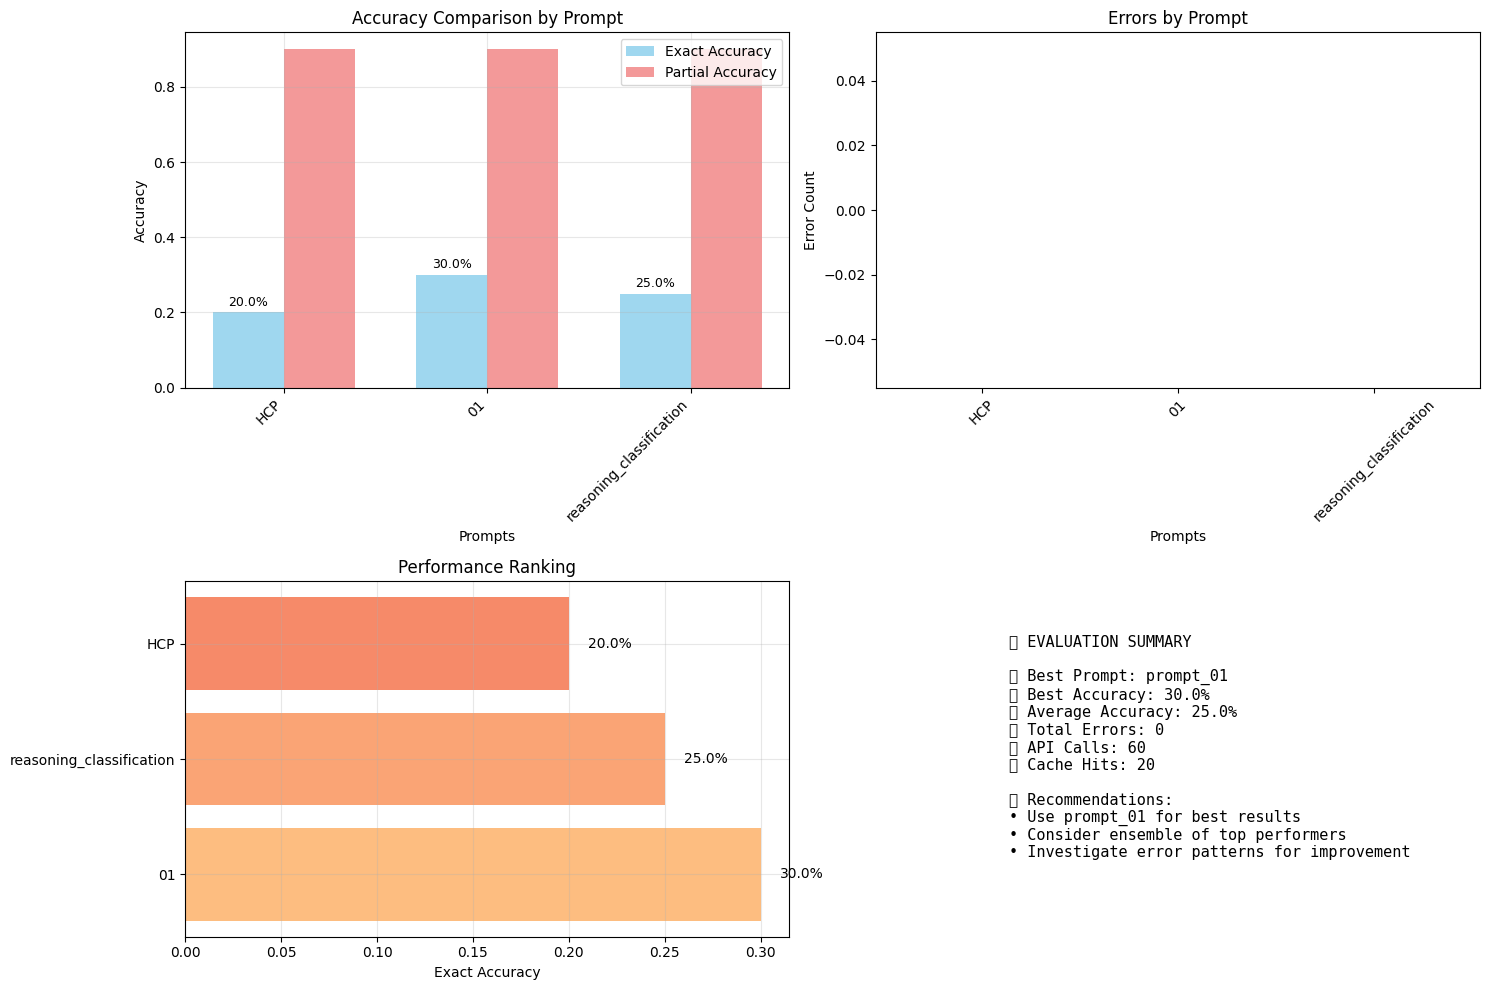

✅ Visualization saved: results\evaluation_results_20250806_123121_analysis.png
✅ Configuration saved: evaluation_results_20250806_123121_config.json

📁 All files saved to: results/


In [18]:
# CELL 7: RESULTS ANALYSIS & EXPORT - Analyze results and save
# ============================================================================

def analyze_results(comparison_results: dict):
    """Detailed analysis with visualizations"""
    
    if comparison_results is None:
        print("❌ No comparison results available. Run Cell 7 first.")
        return
    
    print("🔍 DETAILED RESULTS ANALYSIS")
    print("=" * 60)
    
    all_results = comparison_results['all_results']
    
    # Extract all detailed results
    all_detailed = []
    for result in all_results:
        all_detailed.extend(result['results'])
    
    detailed_df = pd.DataFrame(all_detailed)
    
    # Performance summary
    print("📊 PERFORMANCE SUMMARY:")
    summary_data = []
    for result in all_results:
        metrics = result['metrics']
        summary_data.append({
            'Prompt': result['prompt_name'],
            'Exact_Accuracy': metrics['exact_accuracy'],
            'Partial_Accuracy': metrics['partial_accuracy'],
            'Valid_Predictions': metrics['valid_predictions'],
            'Errors': metrics['error_count']
        })
    
    summary_df = pd.DataFrame(summary_data)
    display(summary_df.round(3))
    
    # Error analysis
    print(f"\n🔍 ERROR ANALYSIS:")
    errors_df = detailed_df[detailed_df['exact_match'] == False]
    
    if len(errors_df) > 0:
        print(f"Found {len(errors_df)} misclassifications:")
        
        # Most common error patterns
        error_patterns = errors_df.groupby(['true_category', 'predicted_category']).size()
        error_patterns = error_patterns.sort_values(ascending=False).head(20)
        
        print(f"\n🔝 Top Error Patterns:")
        for (true_cat, pred_cat), count in error_patterns.items():
            print(f"   • {true_cat} → {pred_cat}: {count} times")
        
        # Errors by prompt
        errors_by_prompt = errors_df.groupby('prompt_name').size().sort_values(ascending=False)
        print(f"\n📊 Errors by Prompt:")
        for prompt, error_count in errors_by_prompt.items():
            total_predictions = len(detailed_df[detailed_df['prompt_name'] == prompt])
            error_rate = error_count / total_predictions * 100
            print(f"   • {prompt}: {error_count}/{total_predictions} ({error_rate:.1f}%)")
    else:
        print("🎉 No errors found! Perfect classification!")
    
    # Show confidence analysis if available
    if 'confidence' in detailed_df.columns:
        print(f"\n🎯 CONFIDENCE ANALYSIS:")
        confidence_counts = detailed_df['confidence'].value_counts()
        for conf, count in confidence_counts.items():
            if conf != 'unknown':
                print(f"   • {conf}: {count} predictions")
    
    return {
        'summary_df': summary_df,
        'detailed_df': detailed_df,
        'errors_df': errors_df
    }

def export_results(comparison_results: dict, filename_prefix: str = None):
    """Export results with timestamps and visualizations"""
    
    if comparison_results is None:
        print("❌ No results to export")
        return
    
    # Create results folder
    os.makedirs(config.RESULTS_FOLDER, exist_ok=True)
    
    if filename_prefix is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename_prefix = f"evaluation_results_{timestamp}"
    
    base_path = os.path.join(config.RESULTS_FOLDER, filename_prefix)
    
    try:
        # Export summary comparison
        comparison_results['comparison_df'].to_csv(f"{base_path}_summary.csv", index=False)
        print(f"✅ Summary saved: {filename_prefix}_summary.csv")
        
        # Export detailed results
        all_detailed = []
        for result in comparison_results['all_results']:
            all_detailed.extend(result['results'])
        
        detailed_df = pd.DataFrame(all_detailed)
        detailed_df.to_csv(f"{base_path}_detailed.csv", index=False)
        print(f"✅ Detailed results saved: {filename_prefix}_detailed.csv")
        
        # Export full results as JSON
        with open(f"{base_path}_full_results.json", 'w') as f:
            json.dump(comparison_results['all_results'], f, indent=2, default=str)
        print(f"✅ Full results saved: {filename_prefix}_full_results.json")
        
        # Create visualization
        create_visualization(comparison_results, base_path)
        
        # Export configuration used
        config_info = {
            'model': config.MODEL,
            'sample_size': config.SAMPLE_SIZE,
            'prompts_tested': config.PROMPTS_TO_TEST,
            'timestamp': datetime.now().isoformat(),
            'api_stats': comparison_results['api_stats']
        }
        
        with open(f"{base_path}_config.json", 'w') as f:
            json.dump(config_info, f, indent=2)
        print(f"✅ Configuration saved: {filename_prefix}_config.json")
        
        print(f"\n📁 All files saved to: {config.RESULTS_FOLDER}/")
        
    except Exception as e:
        print(f"❌ Error exporting results: {e}")

def create_visualization(comparison_results: dict, base_path: str):
    """Create performance visualization"""
    
    try:
        # Extract data for plotting
        prompt_names = []
        exact_accuracies = []
        partial_accuracies = []
        error_counts = []
        
        for result in comparison_results['all_results']:
            prompt_names.append(result['prompt_name'].replace('prompt_', ''))
            exact_accuracies.append(result['metrics']['exact_accuracy'])
            partial_accuracies.append(result['metrics']['partial_accuracy'])
            error_counts.append(result['metrics']['error_count'])
        
        # Create subplots
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # 1. Accuracy comparison
        x = range(len(prompt_names))
        width = 0.35
        
        bars1 = ax1.bar([i - width/2 for i in x], exact_accuracies, width, 
                       label='Exact Accuracy', alpha=0.8, color='skyblue')
        bars2 = ax1.bar([i + width/2 for i in x], partial_accuracies, width, 
                       label='Partial Accuracy', alpha=0.8, color='lightcoral')
        
        ax1.set_xlabel('Prompts')
        ax1.set_ylabel('Accuracy')
        ax1.set_title('Accuracy Comparison by Prompt')
        ax1.set_xticks(x)
        ax1.set_xticklabels(prompt_names, rotation=45, ha='right')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.1%}', ha='center', va='bottom', fontsize=9)
        
        # 2. Error counts
        bars3 = ax2.bar(prompt_names, error_counts, color='salmon', alpha=0.7)
        ax2.set_xlabel('Prompts')
        ax2.set_ylabel('Error Count')
        ax2.set_title('Errors by Prompt')
        ax2.tick_params(axis='x', rotation=45)
        
        for bar in bars3:
            height = bar.get_height()
            if height > 0:
                ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                        f'{int(height)}', ha='center', va='bottom')
        
        # 3. Performance ranking
        performance_data = list(zip(prompt_names, exact_accuracies))
        performance_data.sort(key=lambda x: x[1], reverse=True)
        
        ranked_names, ranked_scores = zip(*performance_data)
        colors = plt.cm.RdYlGn([score for score in ranked_scores])
        
        bars4 = ax3.barh(ranked_names, ranked_scores, color=colors, alpha=0.8)
        ax3.set_xlabel('Exact Accuracy')
        ax3.set_title('Performance Ranking')
        ax3.grid(True, alpha=0.3)
        
        for i, bar in enumerate(bars4):
            width = bar.get_width()
            ax3.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
                    f'{width:.1%}', ha='left', va='center')
        
        # 4. Summary statistics
        ax4.axis('off')
        best_prompt = comparison_results['best_prompt']
        best_accuracy = max(exact_accuracies)
        avg_accuracy = sum(exact_accuracies) / len(exact_accuracies)
        total_errors = sum(error_counts)
        
        summary_text = f"""
        📊 EVALUATION SUMMARY
        
        🏆 Best Prompt: {best_prompt}
        📈 Best Accuracy: {best_accuracy:.1%}
        📊 Average Accuracy: {avg_accuracy:.1%}
        ❌ Total Errors: {total_errors}
        📞 API Calls: {comparison_results['api_stats']['total_requests']}
        💾 Cache Hits: {comparison_results['api_stats']['cache_hits']}
        
        🎯 Recommendations:
        • Use {best_prompt} for best results
        • Consider ensemble of top performers
        • Investigate error patterns for improvement
        """
        
        ax4.text(0.1, 0.9, summary_text, transform=ax4.transAxes, 
                fontsize=11, verticalalignment='top', fontfamily='monospace')
        
        plt.tight_layout()
        plt.savefig(f"{base_path}_analysis.png", dpi=300, bbox_inches='tight')
        plt.show()  # Display in Jupyter
        
        print(f"✅ Visualization saved: {base_path}_analysis.png")
        
    except Exception as e:
        print(f"⚠️ Could not create visualization: {e}")

# Example usage:
if 'comparison_results' in locals() and comparison_results:
    analysis = analyze_results(comparison_results)
    export_results(comparison_results)